# Inflazione e tassi stocastici: pricing Monte Carlo di un inflation-linked bond

## Contesto, domanda quantitativa e variabile finale

**Contesto del caso**
Un investitore deve valutare un'obbligazione i cui flussi dipendono dall'evoluzione futura dell'inflazione. Le cedole sono indicizzate al livello dei prezzi e, a scadenza, il capitale rimborsato non può essere inferiore al valore facciale. La valutazione dipende congiuntamente da due fattori di rischio: il tasso istantaneo di inflazione $i_t$ e il tasso nominale istantaneo privo di rischio $r_t$, i cui shock sono correlati.

**Domanda quantitativa**
Qual è il valore corrente dell'inflation-linked bond ottenuto mediante simulazione Monte Carlo, e quale ruolo assumono l'indicizzazione, il rimborso protetto e la dipendenza tra inflazione e tasso nominale?

**Variabile finale**
Il valore attuale dello strumento ottenuto in ciascuno scenario simulato, $V^{(s)}$. Il prezzo del bond è stimato come valore medio Monte Carlo di tale variabile.

**Informazione disponibile**
Sono assegnati i parametri dei processi stocastici (Ornstein-Uhlenbeck per l'inflazione, CIR per il tasso nominale), la correlazione $\rho$ tra gli shock, la struttura del contratto (scadenza, cedole semestrali, protezione del capitale nominale) e i parametri della simulazione Monte Carlo.

## Quantità da stimare o calcolare

Devono essere determinate almeno le seguenti quantità:

1. prezzo Monte Carlo del bond;
2. errore standard Monte Carlo del prezzo e relativo intervallo di confidenza al 95%;
3. valore attuale medio delle cedole;
4. stima Monte Carlo del valore attuale atteso del rimborso del capitale;
5. probabilità simulata di deflazione cumulata a scadenza, $\widehat{\mathbb P}(J_T<1)$;
6. media e deviazione standard simulate di $i_T$, $r_T$ e $J_T$.

## Output richiesti

### Tabelle

1. tabella dei parametri del caso;
2. tabella di sintesi del pricing, contenente almeno valore attuale medio delle cedole, valore attuale atteso del rimborso del capitale e prezzo complessivo;
3. tabella di diagnostica Monte Carlo per $M=1\,000,\ 5\,000,\ 10\,000,\ 50\,000$, riportando almeno prezzo stimato ed errore standard;
4. tabella delle statistiche terminali di $i_T$, $r_T$ e $J_T$.

### Grafici

1. traiettorie simulate del tasso di inflazione $i_t$;
2. traiettorie simulate del tasso nominale $r_t$;
3. distribuzione simulata di $J_T$;
4. distribuzione dei valori attuali $V^{(s)}$;
5. grafico di convergenza della stima Monte Carlo al crescere di $M$.

## Controlli richiesti

Il notebook deve verificare esplicitamente che:

1. la correlazione empirica degli shock simulati sia coerente con il valore assegnato $\rho=0,25$;
2. $J_t>0$ per costruzione;
3. il rimborso soddisfi in ogni scenario $R_T\geq N$;
4. eventuali valori negativi di $r_t$ generati dalla discretizzazione siano rilevati e documentati come possibile anomalia numerica;
5. la decomposizione del valore sia coerente:

$$
\text{prezzo totale}=\text{valore attuale medio delle cedole}+\text{valore attuale atteso del rimborso}.
$$

6. l'errore standard Monte Carlo diminuisca al crescere di $M$, in modo compatibile con l'ordine $1/\sqrt{M}$;
7. il prezzo sia sufficientemente stabile rispetto a una griglia temporale più fine.

## Specifica vincolante

La Scheda Caso costituisce la specifica vincolante del lavoro e non deve essere modificata. Variabili, formule, parametri, output, controlli e ipotesi non devono essere modificati durante lo svolgimento.

| Tappa | Input | Operazione | Output | Controllo | Uso successivo |
|---|---|---|---|---|---|
| **1. Setup e generazione shock** | Parametri del caso, $M$, $\Delta t$, $\rho$ | Creazione griglia temporale. Generazione di normali standard indipendenti e applicazione della scomposizione di Cholesky per ottenere gli shock correlati $Z_1, Z_2$. | Matrice degli shock browniani correlati $Z_1, Z_2$ di dimensione $M \times \text{passi}$. | Verifica della correlazione empirica degli shock (Controllo 1). | Input per gli schemi di discretizzazione di Tappa 2. |
| **2. Simulazione fattori di rischio** | Parametri $i_0, r_0$, griglia temporale, shock $Z_1, Z_2$ | Applicazione dello schema di Eulero-Maruyama per simulare le traiettorie di $i_t$ (Ornstein-Uhlenbeck) e $r_t$ (CIR). | Matrici delle traiettorie simulate per $i_t$ e $r_t$. | Rilevamento e conteggio di eventuali $r_t < 0$ (Controllo 4). Estrazione statistiche terminali $i_T, r_T$ (Quantità 6). | Input per il calcolo degli integrali in Tappa 3. |
| **3. Indice prezzi e fattore sconto** | Traiettorie $i_t, r_t$, $\Delta t$ | Approssimazione degli integrali $\int i_s ds$ e $\int r_s ds$ (somma di Riemann). Calcolo di $J_t = \exp(\int i_s ds)$ e $D(0,t) = \exp(-\int r_s ds)$. | Matrici per l'indice dei prezzi cumulato $J_t$ e il fattore di sconto $D(0,t)$ in ogni tempo della griglia. | Verifica $J_t > 0$ (Controllo 2). Calcolo probabilità $\widehat{\mathbb P}(J_T<1)$ (Quantità 5). Estrazione statistiche $J_T$ (Quantità 6). | Input per la determinazione dei flussi in Tappa 4. |
| **4. Flussi e valore per scenario** | $J_t$, $D(0,t)$, parametri contratto ($N, c, T$) | Calcolo cedole $C_{t_j}$ nei tempi semestrali, rimborso $R_T = N\max(J_T,1)$. Attualizzazione dei flussi e somma per ottenere $V^{(s)}$. | Array del valore attuale del bond per scenario $V^{(s)}$, array del VA cedole e del VA rimborso. | Verifica $R_T \geq N$ in ogni scenario (Controllo 3). | Input per la stima Monte Carlo in Tappa 5. |
| **5. Stima MC e diagnostica** | Array $V^{(s)}$, VA cedole, VA rimborso | Calcolo del prezzo medio, errore standard $SE = \sigma_V/\sqrt{M}$, intervallo di confidenza al 95%. | Tabelle di sintesi del pricing e diagnostica MC (Quantità 1, 2, 3, 4). | Verifica decomposizione prezzo totale = VA cedole + VA rimborso (Controllo 5). | Input per le analisi di convergenza in Tappa 6. |
| **6. Convergenza e output grafici** | Parametri del caso, dati di Tappa 2, 3, 4, 5 | Esecuzione del loop di simulazione per $M \in [1000, 5000, 10000, 50000]$ e per griglia temporale più fine. Generazione di tutti i grafici richiesti. | Tabelle diagnostiche per vari $M$, grafici delle traiettorie, distribuzioni e convergenza. | Verifica andamento $SE$ al crescere di $M$ (Controllo 6). Verifica stabilità con griglia più fine (Controllo 7). | Conclusione del notebook. |



## Tappa 1.

### Richiesta dello studente
"Costruisci la Tappa 1. Mi sembra utile che l'output sia caratterizzato dalla definizione dei parametri del caso, dalla costruzione della griglia temporale e dalla generazione degli shock casuali correlati per inflazione e tasso. Vorrei anche vedere un controllo che la correlazione ottenuta sia abbastanza vicina a quella assegnata."

### Sintesi logica degli output previsti
La successiva cella di codice eseguirà le seguenti operazioni:

Definizione dei parametri: Istanziazione di tutti i parametri del contratto, dei processi stocastici e della simulazione come variabili Python, secondo i valori della Scheda Caso. Verrà prodotta e visualizzata la tabella dei parametri (Output richiesto 1).
Costruzione della griglia temporale: Creazione di un vettore temporale mensile da 
0
 a 
T=5
 anni.
Generazione degli shock correlati: Estrazione di variabili casuali normali standard indipendenti e applicazione della decomposizione di Cholesky per imporre la correlazione 
ρ=0,25
 tra i due fattori.
Controllo empirico: Calcolo e stampa della correlazione empirica campionaria tra i due vettori di shock generati, per verificare l'adesione al target teorico (Controllo richiesto 1).

In [1]:
import numpy as np
import pandas as pd

# --- 1. Definizione dei parametri del caso ---
# Parametri del contratto
N = 100.0
T = 5.0
c = 0.015
freq_cedole = 2  # semestrale

# Indice prezzi
I0 = 100.0

# Inflazione (Ornstein-Uhlenbeck)
i0 = 0.025
kappa_i = 0.80
theta_i = 0.020
sigma_i = 0.015

# Tasso nominale (CIR)
r0 = 0.030
kappa_r = 1.20
theta_r = 0.030
sigma_r = 0.10

# Dipendenza
rho = 0.25

# Simulazione
dt = 1/12
M = 50000
seed = 12345

# Verifica condizione di Feller per il processo CIR
feller_check = 2 * kappa_r * theta_r >= sigma_r**2
print(f"Verifica condizione di Feller (2*kappa_r*theta_r >= sigma_r^2): {feller_check}")

# Creazione della tabella dei parametri (Output richiesto - Tabella 1)
param_data = {
    "Componente": ["Contratto", "Contratto", "Contratto", "Contratto", "Indice prezzi", 
                   "Inflazione OU", "Inflazione OU", "Inflazione OU", "Inflazione OU",
                   "Tasso CIR", "Tasso CIR", "Tasso CIR", "Tasso CIR",
                   "Dipendenza", "Simulazione", "Simulazione", "Simulazione"],
    "Parametro": ["N", "T", "c", "frequenza cedole", "I0", 
                  "i0", "kappa_i", "theta_i", "sigma_i",
                  "r0", "kappa_r", "theta_r", "sigma_r",
                  "rho", "dt", "M", "seed"],
    "Valore": [N, T, c, freq_cedole, I0, 
               i0, kappa_i, theta_i, sigma_i,
               r0, kappa_r, theta_r, sigma_r,
               rho, dt, M, seed]
}
df_params = pd.DataFrame(param_data)
print("\n--- Tabella 1: Parametri del caso ---")
display(df_params)

# --- 2. Costruzione della griglia temporale ---
n_steps = int(T / dt)
time_grid = np.linspace(0, T, n_steps + 1)

# --- 3. Generazione degli shock casuali correlati ---
np.random.seed(seed)

# Generazione di shock indipendenti N(0,1)
Z1_indep = np.random.normal(0, 1, size=(M, n_steps))
Z2_indep = np.random.normal(0, 1, size=(M, n_steps))

# Scomposizione di Cholesky: 
# Z1 = Z1_indep
# Z2 = rho * Z1_indep + sqrt(1 - rho^2) * Z2_indep
Z1 = Z1_indep
Z2 = rho * Z1_indep + np.sqrt(1 - rho**2) * Z2_indep

# --- 4. Controllo empirico della correlazione (Controllo richiesto 1) ---
# Calcoliamo la correlazione empirica tra i vettori di shock
empirical_corr = np.corrcoef(Z1.flatten(), Z2.flatten())[0, 1]

print("\n--- Controllo 1: Correlazione empirica degli shock ---")
print(f"Correlazione target (rho):   {rho:.4f}")
print(f"Correlazione empirica:       {empirical_corr:.4f}")
print(f"Scarto assoluto:             {abs(empirical_corr - rho):.6f}")

Verifica condizione di Feller (2*kappa_r*theta_r >= sigma_r^2): True

--- Tabella 1: Parametri del caso ---


,Componente,Parametro,Valore
0,Contratto,N,100.000000
1,Contratto,T,5.000000
2,Contratto,c,0.015000
3,Contratto,frequenza cedole,2.000000
4,Indice prezzi,I0,100.000000
5,Inflazione OU,i0,0.025000
6,Inflazione OU,kappa_i,0.800000
7,Inflazione OU,theta_i,0.020000
8,Inflazione OU,sigma_i,0.015000
9,Tasso CIR,r0,0.030000



--- Controllo 1: Correlazione empirica degli shock ---
Correlazione target (rho):   0.2500
Correlazione empirica:       0.2505
Scarto assoluto:             0.000520


## Tappa 2.

### Richiesta dello studente
"A questo punto bisogna usare gli shock generati prima per simulare le traiettorie dell’inflazione e del tasso nominale con i due modelli assegnati. Mi sembra importante ottenere le matrici delle traiettorie e controllare se nella simulazione del CIR compaiono valori negativi del tasso. Gradirei che l'output fosse formattato ove possibile in tabelle"

### Sintesi logica degli output previsti
La successiva cella di codice eseguirà le seguenti operazioni:
1. **Inizializzazione delle traiettorie**: Creazione di due matrici di dimensione $M \times (\text{numero di step} + 1)$ per memorizzare i cammini di $i_t$ e $r_t$, impostando i valori iniziali $i_0$ e $r_0$.
2. **Ciclo di simulazione (Eulero-Maruyama)**: Evoluzione delle traiettorie passo per passo. Per il CIR, al fine di evitare errori numerici nella radice quadrata, si utilizzerà $\max(r_t, 0)$ all'interno del termine di diffusione, ma senza troncare il valore del tasso stesso, in modo da poter rilevare le eventuali anomalie.
3. **Controllo delle anomalie (Controllo 4)**: Verifica esplicita del numero di valori negativi assunti dal tasso $r_t$ nelle matrici simulate e conteggio degli scenari in cui ciò si verifica.
4. **Estrazione delle statistiche terminali (parziale)**: Calcolo della media e della deviazione standard dei valori finali $i_T$ e $r_T$, formattati in una tabella.
5. **Anteprima tabellare**: Visualizzazione di un estratto delle traiettorie simulate per i primi scenari e step temporali.

In [2]:
# --- 1. Inizializzazione delle matrici delle traiettorie ---
# Dimensioni: M scenari per n_steps + 1 punti temporali (incluso t=0)
i_paths = np.zeros((M, n_steps + 1))
r_paths = np.zeros((M, n_steps + 1))

# Condizioni iniziali
i_paths[:, 0] = i0
r_paths[:, 0] = r0

# --- 2. Simulazione delle traiettorie (Schema di Eulero-Maruyama) ---
for t in range(n_steps):
    # Processo Ornstein-Uhlenbeck per l'inflazione
    i_paths[:, t+1] = i_paths[:, t] + kappa_i * (theta_i - i_paths[:, t]) * dt + sigma_i * np.sqrt(dt) * Z1[:, t]
    
    # Processo CIR per il tasso nominale
    # Si utilizza max(r_t, 0) all'interno della radice per evitare errori numerici (NaN),
    # ma il valore del tasso r_{t+dt} non viene forzato a zero se diventa negativo,
    # per permettere il rilevamento dell'anomalia numerica.
    r_t_current = r_paths[:, t]
    diffusion_term = sigma_r * np.sqrt(np.maximum(r_t_current, 0) * dt) * Z2[:, t]
    r_paths[:, t+1] = r_paths[:, t] + kappa_r * (theta_r - r_paths[:, t]) * dt + diffusion_term

# --- 3. Controllo 4: Rilevamento anomalie numeriche (r_t < 0) ---
negative_rates_mask = r_paths < 0
negative_rates_count = np.sum(negative_rates_mask)
negative_rates_scenarios = np.sum(np.any(negative_rates_mask, axis=1))

print("--- Controllo 4: Rilevamento anomalie numeriche (r_t < 0) ---")
print(f"Totale valori negativi generati nella matrice r_paths: {negative_rates_count}")
print(f"Numero di scenari con almeno un valore negativo: {negative_rates_scenarios} su {M}")
if negative_rates_count > 0:
    print("Attenzione: la discretizzazione Eulero-Maruyama ha generato valori negativi per il tasso CIR.")
    print("Ciò è una nota anomalia numerica del metodo di discretizzazione. I valori negativi sono stati mantenuti per il rilevamento.")
else:
    print("Nessun valore negativo rilevato per il tasso CIR nella simulazione.")

# --- 4. Estrazione valori terminali e statistiche (parziale, manca J_T) ---
i_T = i_paths[:, -1]
r_T = r_paths[:, -1]

# Creazione tabella delle statistiche terminali
stats_data = {
    "Variabile": ["i_T", "r_T"],
    "Media": [np.mean(i_T), np.mean(r_T)],
    "Deviazione Standard": [np.std(i_T, ddof=1), np.std(r_T, ddof=1)]
}
df_stats = pd.DataFrame(stats_data)
print("\n--- Statistiche terminali (parziale) ---")
display(df_stats)

# --- 5. Anteprima delle matrici delle traiettorie ---
print("\n--- Anteprima traiettorie simulate (primi 2 scenari, primi 4 step) ---")
df_paths_preview = pd.DataFrame({
    "Tempo (anni)": time_grid[:4],
    "i_t (Scenario 1)": i_paths[0, :4],
    "r_t (Scenario 1)": r_paths[0, :4],
    "i_t (Scenario 2)": i_paths[1, :4],
    "r_t (Scenario 2)": r_paths[1, :4]
})
display(df_paths_preview)

--- Controllo 4: Rilevamento anomalie numeriche (r_t < 0) ---
Totale valori negativi generati nella matrice r_paths: 3
Numero di scenari con almeno un valore negativo: 3 su 50000
Attenzione: la discretizzazione Eulero-Maruyama ha generato valori negativi per il tasso CIR.
Ciò è una nota anomalia numerica del metodo di discretizzazione. I valori negativi sono stati mantenuti per il rilevamento.

--- Statistiche terminali (parziale) ---


,Variabile,Media,Deviazione Standard
0,i_T,0.020101,0.012119
1,r_T,0.029982,0.011447



--- Anteprima traiettorie simulate (primi 2 scenari, primi 4 step) ---


,Tempo (anni),i_t (Scenario 1),r_t (Scenario 1),i_t (Scenario 2),r_t (Scenario 2)
0,0.000000,0.025000,0.030000,0.025000,0.030000
1,0.083333,0.023780,0.016160,0.028402,0.026936
2,0.166667,0.025602,0.015038,0.027798,0.030936
3,0.250000,0.022979,0.018659,0.027495,0.026761


### Richiesta dello studente
"Costruisci la Tappa 3.
Ora bisogna Approssimare gli integrali $\int i_s ds$ e $\int r_s ds$ (somma di Riemann). Calcolo di $J_t = \exp(\int i_s ds)$ e $D(0,t) = \exp(-\int r_s ds)$.
Completa ove necessario la tappa 3."

### Sintesi logica degli output previsti
La successiva cella di codice eseguirà le seguenti operazioni:
1. **Approssimazione degli integrali**: Calcolo delle matrici contenenti gli integrali cumulativi $\int_0^t i_s ds$ e $\int_0^t r_s ds$ tramite somma di Riemann (utilizzando il metodo del rettangolo a sinistra, coerentemente con lo schema di Eulero-Maruyama).
2. **Costruzione dell'indice e del fattore di sconto**: Ottenimento delle matrici $J_t$ e $D(0,t)$ applicando l'esponenziale ai risultati degli integrali.
3. **Controllo di positività (Controllo 2)**: Verifica formale che la matrice $J_t$ contenga esclusivamente valori strettamente positivi.
4. **Probabilità di deflazione (Quantità 5)**: Estrazione del valore terminale $J_T$ e calcolo della probabilità simulata $\widehat{\mathbb P}(J_T<1)$.
5. **Completamento statistiche terminali (Quantità 6)**: Aggiornamento e stampa della tabella delle statistiche terminali includendo media e deviazione standard di $J_T$.

In [3]:
# --- 1. Approssimazione degli integrali (Somma di Riemanna a sinistra) ---
# Escludiamo l'ultimo step per l'integrale (integrale da 0 a t step precedente)
# e inseriamo uno zero all'inizio per rappresentare l'integrale da 0 a 0.
integral_i = np.cumsum(i_paths[:, :-1] * dt, axis=1)
integral_i = np.hstack([np.zeros((M, 1)), integral_i])

integral_r = np.cumsum(r_paths[:, :-1] * dt, axis=1)
integral_r = np.hstack([np.zeros((M, 1)), integral_r])

# --- 2. Calcolo di J_t e D(0,t) ---
J_t = np.exp(integral_i)
D_t = np.exp(-integral_r)

# --- 3. Controllo 2: Verifica J_t > 0 ---
# Per costruzione matematica (essendo l'esponenziale di un numero reale), 
# J_t deve essere strettamente positivo. Verifichiamo tuttavia la matrice.
check_J_positive = np.all(J_t > 0)
print("--- Controllo 2: Verifica J_t > 0 ---")
print(f"Tutti i valori di J_t sono strettamente positivi? {check_J_positive}")

# --- 4. Quantità 5: Probabilità di deflazione cumulata a scadenza ---
J_T = J_t[:, -1]
prob_deflazione = np.mean(J_T < 1)

print("\n--- Quantità 5: Probabilità simulata di deflazione cumulata a scadenza ---")
print(f"P(J_T < 1) = {prob_deflazione:.4f} ({prob_deflazione*100:.2f}%)")

# --- 5. Completamento statistiche terminali (Quantità 6) ---
stats_data_complete = {
    "Variabile": ["i_T", "r_T", "J_T"],
    "Media": [np.mean(i_T), np.mean(r_T), np.mean(J_T)],
    "Deviazione Standard": [np.std(i_T, ddof=1), np.std(r_T, ddof=1), np.std(J_T, ddof=1)]
}
df_stats_complete = pd.DataFrame(stats_data_complete)
print("\n--- Statistiche terminali complete (Quantità 6) ---")
display(df_stats_complete)


--- Controllo 2: Verifica J_t > 0 ---
Tutti i valori di J_t sono strettamente positivi? True

--- Quantità 5: Probabilità simulata di deflazione cumulata a scadenza ---
P(J_T < 1) = 0.0007 (0.07%)

--- Statistiche terminali complete (Quantità 6) ---


,Variabile,Media,Deviazione Standard
0,i_T,0.020101,0.012119
1,r_T,0.029982,0.011447
2,J_T,1.112806,0.037117


## Tappa 4.
### Richiesta dello studente
"Costruisci la Tappa 4.
Secondo me Ora bisogna procedere con Calcolo cedole $C_{t_j}$ nei tempi semestrali, rimborso $R_T = N\max(J_T,1)$. Attualizzazione dei flussi e somma per ottenere $V^{(s)}$.
Completa ove necessario tappa 4"

### Sintesi logica degli output previsti
La successiva cella di codice eseguirà le seguenti operazioni:
1. **Identificazione delle date di pagamento**: Selezione degli indici della griglia temporale mensile corrispondenti alle scadenze semestrali ($t_j = 0.5, 1.0, \dots, 5.0$ anni).
2. **Calcolo dei flussi contrattuali**: 
   - Determinazione delle cedole indicizzate $C_{t_j} = \frac{c}{2} N J_{t_j}$.
   - Determinazione del rimborso protetto a scadenza $R_T = N\max(J_T, 1)$.
3. **Controllo del rimborso (Controllo 3)**: Verifica esplicita che in ogni scenario simulato il rimborso soddisfi la condizione $R_T \geq N$.
4. **Attualizzazione e valore per scenario**: Calcolo dei valori attuali delle cedole e del rimborso utilizzando i fattori di sconto estratti ai tempi corretti. Somma degli stessi per ottenere il valore attuale del bond in ogni scenario, $V^{(s)}$.
5. **Anteprima tabellare**: Estrazione e visualizzazione di un sommario dei flussi attualizzati e del valore totale per i primi scenari simulati.

In [4]:
# --- 1. Identificazione delle date di pagamento delle cedole ---
# La griglia è mensile (dt = 1/12). Le cedole sono semestrali (ogni 6 mesi).
step_per_cedola = int(0.5 / dt)  # 6 step mensili
coupon_indices = np.arange(step_per_cedola, n_steps + 1, step_per_cedola)

print(f"Date di pagamento delle cedole (anni): {time_grid[coupon_indices]}")

# --- 2. Calcolo dei flussi contrattuali ---
# Cedole indicizzate ai tempi t_j
C_tj = (c / freq_cedole) * N * J_t[:, coupon_indices]

# Rimborso protetto a scadenza
R_T = N * np.maximum(J_T, 1)

# --- 3. Controllo 3: Verifica R_T >= N ---
check_R_T = np.all(R_T >= N)
min_R_T = np.min(R_T)

print("\n--- Controllo 3: Rimborso del capitale ---")
print(f"Tutti gli scenari soddisfano la condizione R_T >= N? {check_R_T}")
print(f"Valore minimo del rimborso simulato: {min_R_T:.4f} (N = {N})")

# --- 4. Attualizzazione dei flussi e calcolo V^{(s)} ---
# Fattori di sconto alle date delle cedole e a scadenza
D_tj = D_t[:, coupon_indices]
D_T = D_t[:, -1]

# Valori attuali per scenario
PV_coupons = C_tj * D_tj
PV_repayment = R_T * D_T

# Valore attuale totale del bond per ogni scenario s
total_PV_coupons = np.sum(PV_coupons, axis=1)
V_s = total_PV_coupons + PV_repayment

# --- 5. Anteprima tabellare ---
print("\n--- Anteprima Valori Attuali per scenario (primi 5 scenari) ---")
df_V_preview = pd.DataFrame({
    "Scenario": np.arange(1, 6),
    "VA Cedole Totali": total_PV_coupons[:5],
    "VA Rimborso": PV_repayment[:5],
    "V^(s) Totale": V_s[:5]
})
display(df_V_preview.round(4))

Date di pagamento delle cedole (anni): [0.5 1.  1.5 2.  2.5 3.  3.5 4.  4.5 5. ]

--- Controllo 3: Rimborso del capitale ---
Tutti gli scenari soddisfano la condizione R_T >= N? True
Valore minimo del rimborso simulato: 100.0000 (N = 100.0)

--- Anteprima Valori Attuali per scenario (primi 5 scenari) ---


,Scenario,VA Cedole Totali,VA Rimborso,V^(s) Totale
0,1,7.6238,100.7954,108.4192
1,2,7.4419,99.2641,106.7059
2,3,7.3066,95.4047,102.7112
3,4,7.5275,99.3186,106.8461
4,5,7.2421,91.6474,98.8895


## Tappa 5.
### Richiesta dello studente
"Titolo: Tappa 5.
Ora bisogna procedere con Calcolo del prezzo medio, errore standard $SE = \sigma_V/\sqrt{M}$, intervallo di confidenza al 95%. | Tabelle di sintesi del pricing e diagnostica MC (Quantità 1, 2, 3, 4)."

### Sintesi logica degli output previsti
La successiva cella di codice eseguirà le seguenti operazioni:
1. **Calcolo delle quantità principali (Quantità 1, 2, 3, 4)**: 
   - Stima del prezzo Monte Carlo come media di $V^{(s)}$.
   - Calcolo della deviazione standard campionaria di $V^{(s)}$ e dell'errore standard $SE = \sigma_V/\sqrt{M}$.
   - Determinazione dell'intervallo di confidenza al 95% (usando il quantile $z_{0.975} \approx 1.96$).
   - Calcolo del valore attuale medio delle cedole e del valore attuale atteso del rimborso.
2. **Controllo della decomposizione (Controllo 5)**: Verifica numerica che il prezzo totale sia esattamente uguale alla somma del valore attuale medio delle cedole e del valore attuale atteso del rimborso.
3. **Formattazione dell'output (Tabella 2)**: Creazione e visualizzazione di una tabella di sintesi del pricing che racchiude tutte le quantità calcolate.

--- Controllo 5: Decomposizione del valore ---
Prezzo totale stimato (MC):       103.137556
Somma (VA cedole + VA rimborso):  103.137556
Decomposizione coerente?          True

--- Tabella 2: Sintesi del pricing Monte Carlo ---


,Metrica,Valore
0,Valore attuale medio delle cedole,7.337630
1,Valore attuale atteso del rimborso,95.799926
2,Prezzo complessivo (MC),103.137556
3,Errore standard (SE),0.016874
4,Intervallo di confidenza 95% - Limite inferiore,103.104484
5,Intervallo di confidenza 95% - Limite superiore,103.170627


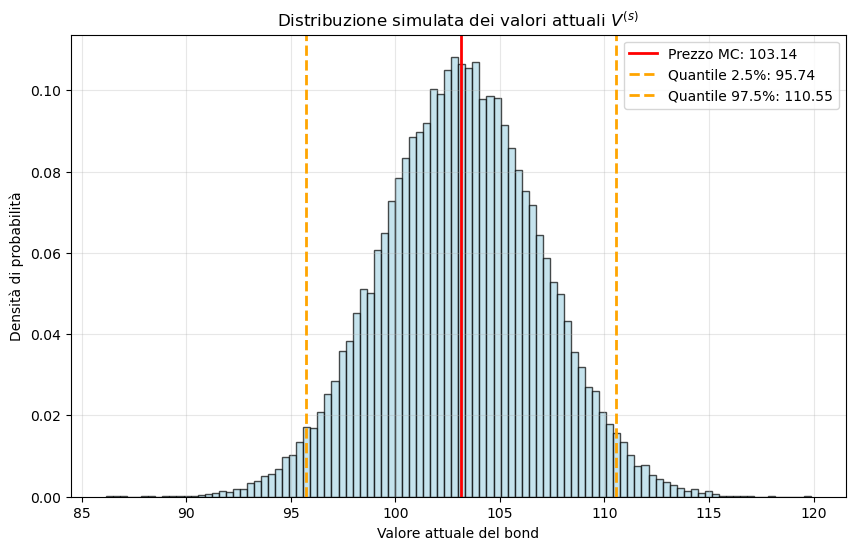

In [7]:
import matplotlib.pyplot as plt
from scipy.stats import norm

# --- 1. Calcolo delle quantità principali (Quantità 1, 2, 3, 4) ---
# Quantità 1: Prezzo Monte Carlo del bond
prezzo_MC = np.mean(V_s)

# Quantità 2: Errore standard e intervallo di confidenza al 95% della stima
std_V = np.std(V_s, ddof=1)
SE = std_V / np.sqrt(M)
z = norm.ppf(0.975) # quantile 97.5% della normale standard (~1.96)
lower_bound = prezzo_MC - z * SE
upper_bound = prezzo_MC + z * SE

# Quantità 3: Valore attuale medio delle cedole
VA_cedole_medio = np.mean(total_PV_coupons)

# Quantità 4: Valore attuale atteso del rimborso del capitale
VA_rimborso_atteso = np.mean(PV_repayment)

# --- 2. Controllo 5: Coerenza della decomposizione del valore ---
somma_componenti = VA_cedole_medio + VA_rimborso_atteso
check_decomposizione = np.isclose(prezzo_MC, somma_componenti)

print("--- Controllo 5: Decomposizione del valore ---")
print(f"Prezzo totale stimato (MC):       {prezzo_MC:.6f}")
print(f"Somma (VA cedole + VA rimborso):  {somma_componenti:.6f}")
print(f"Decomposizione coerente?          {check_decomposizione}")

# --- 3. Formattazione output (Tabella 2: Sintesi del pricing) ---
print("\n--- Tabella 2: Sintesi del pricing Monte Carlo ---")
pricing_data = {
    "Metrica": [
        "Valore attuale medio delle cedole",
        "Valore attuale atteso del rimborso",
        "Prezzo complessivo (MC)",
        "Errore standard (SE)",
        "Intervallo di confidenza 95% - Limite inferiore",
        "Intervallo di confidenza 95% - Limite superiore"
    ],
    "Valore": [
        VA_cedole_medio,
        VA_rimborso_atteso,
        prezzo_MC,
        SE,
        lower_bound,
        upper_bound
    ]
}
df_pricing = pd.DataFrame(pricing_data)
display(df_pricing.round(6))

# --- 4. Grafico 4: Distribuzione dei valori attuali V^{(s)} ---
# Calcolo dei quantili empirici al 2.5% e 97.5% della distribuzione di V^{(s)}
q_lower = np.percentile(V_s, 2.5)
q_upper = np.percentile(V_s, 97.5)

plt.figure(figsize=(10, 6))
plt.hist(V_s, bins=100, color='lightblue', edgecolor='black', alpha=0.7, density=True)
plt.axvline(prezzo_MC, color='red', linestyle='-', linewidth=2, label=f'Prezzo MC: {prezzo_MC:.2f}')
plt.axvline(q_lower, color='orange', linestyle='--', linewidth=2, label=f'Quantile 2.5%: {q_lower:.2f}')
plt.axvline(q_upper, color='orange', linestyle='--', linewidth=2, label=f'Quantile 97.5%: {q_upper:.2f}')

plt.title('Distribuzione simulata dei valori attuali $V^{(s)}$')
plt.xlabel('Valore attuale del bond')
plt.ylabel('Densità di probabilità')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Richiesta dello studente
"Costruisci la Tappa 6.
Secondo me, Ora bisogna procedere con Esecuzione del loop di simulazione per $M \in [1000, 5000, 10000, 50000]$ e per griglia temporale più fine. Generazione di tutti i grafici richiesti. | Tabelle diagnostiche per vari $M$, grafici delle traiettorie, distribuzioni e convergenza.
Completa ove necessario la tappa 6."

### Sintesi logica degli output previsti
La successiva cella di codice eseguirà le seguenti operazioni:
1. **Definizione di una funzione di simulazione aggregata**: Creazione di una funzione Python che ingloba le Tappe da 1 a 5, per consentire l'esecuzione di simulazioni con parametri variabili (numero di scenari $M$ e step temporale $\Delta t$) in modo efficiente.
2. **Controllo di stabilità (Controllo 7)**: Esecuzione della simulazione con $M=50.000$ e una griglia temporale più fine ($\Delta t = 1/24$) per verificare la stabilità del prezzo stimato rispetto alla griglia base mensile.
3. **Diagnostica Monte Carlo (Tabella 3 e Controllo 6)**: Estrazione di sottocampioni di dimensione $M \in [1000, 5000, 10000, 50000]$ dal run principale a $50.000$ scenari per calcolare prezzo stimato ed errore standard. Verifica che l'errore standard diminuisca in modo compatibile con l'ordine $1/\sqrt{M}$.
4. **Generazione dei grafici richiesti**:
   - *Figura 1*: Traiettory simulate del tasso di inflazione $i_t$.
   - *Figura 2*: Traiettory simulate del tasso nominale $r_t$.
   - *Figura 3*: Distribuzione simulata di $J_T$.
   - *Figura 5*: Grafico di convergenza della stima Monte Carlo al crescere di $M$.
   *(Si ricorda che la Figura 4, distribuzione di $V^{(s)}$, è già stata prodotta e validata nella Tappa 5).*

--- Controllo 7: Stabilità rispetto alla griglia temporale ---
Prezzo con dt=1/12 (mensile):      103.1376 (SE: 0.0169)
Prezzo con dt=1/24 (quindicinale): 103.1183 (SE: 0.0168)
Differenza assoluta:               0.0192

--- Quantità 5: Probabilità simulata di deflazione cumulata a scadenza ---
P(J_T < 1) = 0.0007 (0.07%)

--- Tabella 3: Diagnostica Monte Carlo per vari M ---


,M,Prezzo Stimato,Errore Standard (SE),SE Teorico (1/sqrt(M))
0,1000,103.211658,0.117503,0.119315
1,5000,103.161051,0.053322,0.053359
2,10000,103.152643,0.037994,0.037731
3,50000,103.137556,0.016874,0.016874


Controllo 6: L'errore standard diminuisce al crescere di M? True


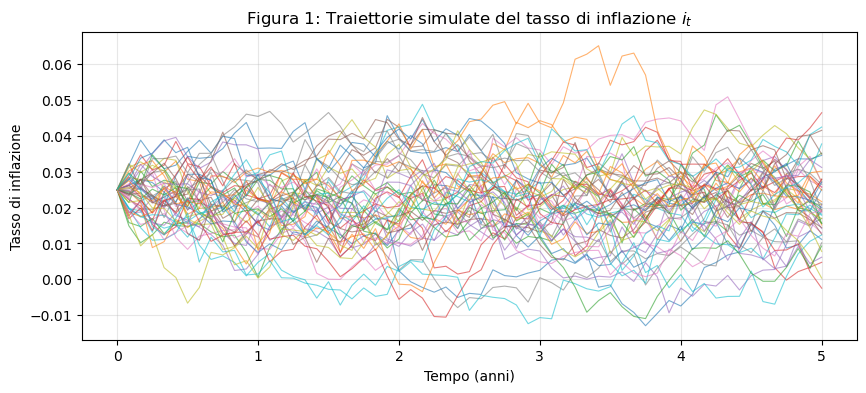

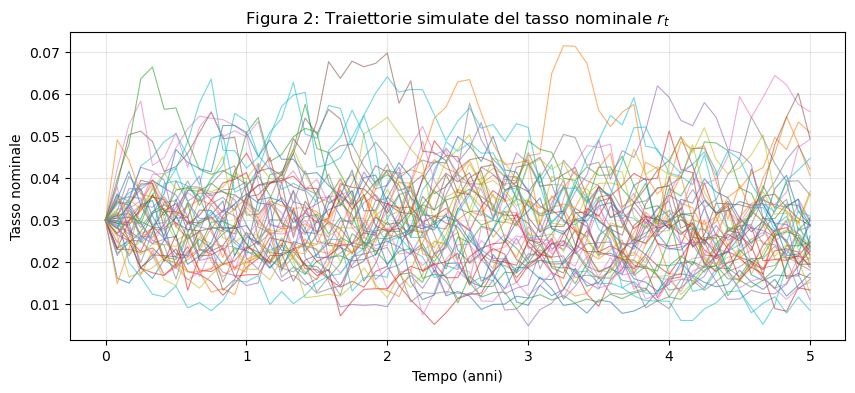

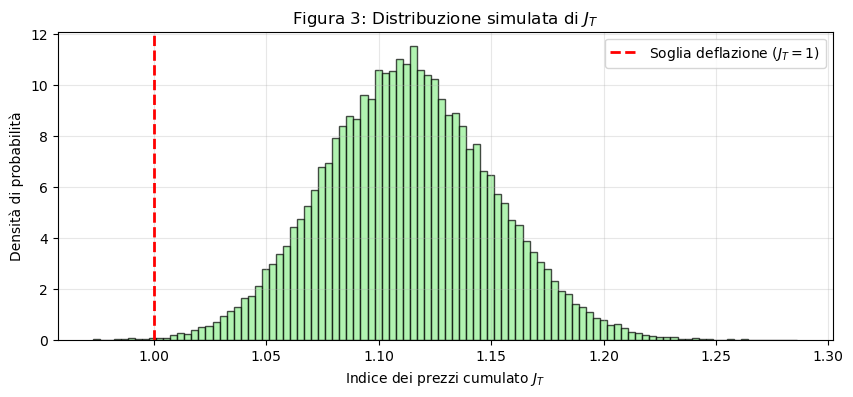

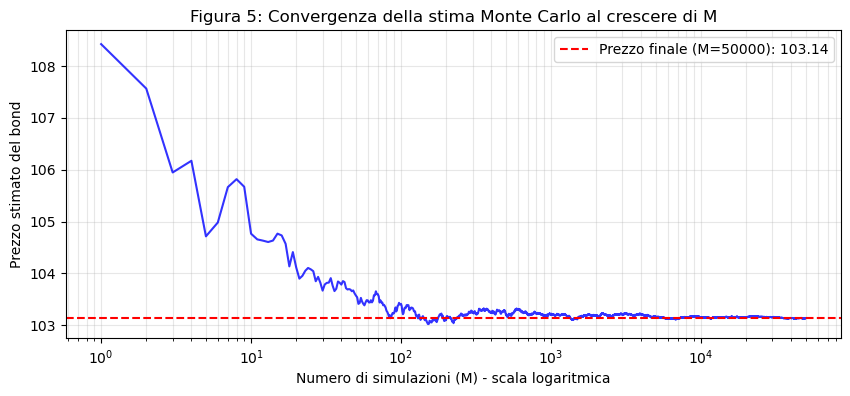

In [9]:
import matplotlib.pyplot as plt
import numpy as np

# --- 1. Funzione aggregata per la simulazione ---
def simulate_bond(M_val, dt_val, seed_val):
    np.random.seed(seed_val)
    n_steps_val = int(T / dt_val)
    
    # Tappa 1: Shock
    Z1_indep = np.random.normal(0, 1, size=(M_val, n_steps_val))
    Z2_indep = np.random.normal(0, 1, size=(M_val, n_steps_val))
    Z1 = Z1_indep
    Z2 = rho * Z1_indep + np.sqrt(1 - rho**2) * Z2_indep
    
    # Tappa 2: Traiettorie
    i_p = np.zeros((M_val, n_steps_val + 1))
    r_p = np.zeros((M_val, n_steps_val + 1))
    i_p[:, 0] = i0
    r_p[:, 0] = r0
    for t in range(n_steps_val):
        i_p[:, t+1] = i_p[:, t] + kappa_i * (theta_i - i_p[:, t]) * dt_val + sigma_i * np.sqrt(dt_val) * Z1[:, t]
        r_t_current = r_p[:, t]
        diffusion_term = sigma_r * np.sqrt(np.maximum(r_t_current, 0) * dt_val) * Z2[:, t]
        r_p[:, t+1] = r_p[:, t] + kappa_r * (theta_r - r_p[:, t]) * dt_val + diffusion_term
        
    # Tappa 3: Indice e Sconto
    int_i = np.cumsum(i_p[:, :-1] * dt_val, axis=1)
    int_i = np.hstack([np.zeros((M_val, 1)), int_i])
    int_r = np.cumsum(r_p[:, :-1] * dt_val, axis=1)
    int_r = np.hstack([np.zeros((M_val, 1)), int_r])
    
    J_t_val = np.exp(int_i)
    D_t_val = np.exp(-int_r)
    J_T_val = J_t_val[:, -1]
    
    # Tappa 4: Flussi e V_s
    step_per_cedola_val = int(0.5 / dt_val)
    coupon_idx = np.arange(step_per_cedola_val, n_steps_val + 1, step_per_cedola_val)
    
    C_tj_val = (c / 2) * N * J_t_val[:, coupon_idx]
    R_T_val = N * np.maximum(J_T_val, 1)
    
    PV_coupons_val = C_tj_val * D_t_val[:, coupon_idx]
    PV_repayment_val = R_T_val * D_t_val[:, -1]
    
    V_s_val = np.sum(PV_coupons_val, axis=1) + PV_repayment_val
    
    # Tappa 5: Statistiche e Probabilità
    prezzo = np.mean(V_s_val)
    se = np.std(V_s_val, ddof=1) / np.sqrt(M_val)
    prob_deflazione = np.mean(J_T_val < 1)
    
    return prezzo, se, prob_deflazione, i_p, r_p, J_T_val, V_s_val

# --- 2. Controllo 7: Stabilità con griglia temporale più fine ---
prezzo_dt12, se_dt12, prob_def_12, i_paths_12, r_paths_12, J_T_12, V_s_12 = simulate_bond(50000, 1/12, seed)
prezzo_dt24, se_dt24, _, _, _, _, _ = simulate_bond(50000, 1/24, seed)

print("--- Controllo 7: Stabilità rispetto alla griglia temporale ---")
print(f"Prezzo con dt=1/12 (mensile):      {prezzo_dt12:.4f} (SE: {se_dt12:.4f})")
print(f"Prezzo con dt=1/24 (quindicinale): {prezzo_dt24:.4f} (SE: {se_dt24:.4f})")
print(f"Differenza assoluta:               {abs(prezzo_dt12 - prezzo_dt24):.4f}")

# --- 3. Quantità 5: Probabilità simulata di deflazione cumulata a scadenza ---
print(f"\n--- Quantità 5: Probabilità simulata di deflazione cumulata a scadenza ---")
print(f"P(J_T < 1) = {prob_def_12:.4f} ({prob_def_12*100:.2f}%)")

# --- 4. Tabella 3 e Controllo 6: Diagnostica MC per vari M ---
M_list = [1000, 5000, 10000, 50000]
diag_data = []

for M_val in M_list:
    V_s_subset = V_s_12[:M_val]
    price_val = np.mean(V_s_subset)
    se_val = np.std(V_s_subset, ddof=1) / np.sqrt(M_val)
    se_teorico = np.std(V_s_12, ddof=1) / np.sqrt(M_val)
    diag_data.append({
        "M": M_val,
        "Prezzo Stimato": price_val,
        "Errore Standard (SE)": se_val,
        "SE Teorico (1/sqrt(M))": se_teorico
    })

df_diag = pd.DataFrame(diag_data)
print("\n--- Tabella 3: Diagnostica Monte Carlo per vari M ---")
display(df_diag.round(6))

# Verifica esplicita del decremento dell'errore (correzione Pylance: cast a float array)
se_values = df_diag["Errore Standard (SE)"].to_numpy(dtype=float)
check_decreasing = np.all(np.diff(se_values) < 0)
print(f"Controllo 6: L'errore standard diminuisce al crescere di M? {check_decreasing}")

# --- 5. Generazione dei Grafici richiesti ---
# Figura 1: Traiettorie simulate del tasso di inflazione i_t
plt.figure(figsize=(10, 4))
time_plot = np.linspace(0, T, int(T/(1/12)) + 1)
for s in range(50):
    plt.plot(time_plot, i_paths_12[s, :], alpha=0.6, linewidth=0.8)
plt.title('Figura 1: Traiettorie simulate del tasso di inflazione $i_t$')
plt.xlabel('Tempo (anni)')
plt.ylabel('Tasso di inflazione')
plt.grid(True, alpha=0.3)
plt.show()

# Figura 2: Traiettorie simulate del tasso nominale r_t
plt.figure(figsize=(10, 4))
for s in range(50):
    plt.plot(time_plot, r_paths_12[s, :], alpha=0.6, linewidth=0.8)
plt.title('Figura 2: Traiettorie simulate del tasso nominale $r_t$')
plt.xlabel('Tempo (anni)')
plt.ylabel('Tasso nominale')
plt.grid(True, alpha=0.3)
plt.show()

# Figura 3: Distribuzione simulata di J_T
plt.figure(figsize=(10, 4))
plt.hist(J_T_12, bins=100, color='lightgreen', edgecolor='black', alpha=0.7, density=True)
plt.axvline(1.0, color='red', linestyle='--', linewidth=2, label='Soglia deflazione ($J_T=1$)')
plt.title('Figura 3: Distribuzione simulata di $J_T$')
plt.xlabel('Indice dei prezzi cumulato $J_T$')
plt.ylabel('Densità di probabilità')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Figura 5: Convergenza della stima Monte Carlo
cum_mean = np.cumsum(V_s_12) / np.arange(1, 50001)

plt.figure(figsize=(10, 4))
plt.plot(np.arange(1, 50001), cum_mean, color='blue', alpha=0.8)
plt.xscale('log')
plt.title('Figura 5: Convergenza della stima Monte Carlo al crescere di M')
plt.xlabel('Numero di simulazioni (M) - scala logaritmica')
plt.ylabel('Prezzo stimato del bond')
plt.axhline(prezzo_dt12, color='red', linestyle='--', linewidth=1.5, label=f'Prezzo finale (M=50000): {prezzo_dt12:.2f}')
plt.legend()
plt.grid(True, alpha=0.3, which='both')
plt.show()